In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *

In [10]:
def find_closest_centroids(X, centroids):
    # X shape: (m, n)
    # centroids shape: (K, n)
    
    # 1. Expand dimensions to compute distances between all points and all centroids simultaneously
    # (m, 1, n) - (1, K, n) results in a distance matrix of shape (m, K, n)
    distances = np.sum((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2, axis=2)
    
    # 2. Find the index of the closest centroid along the cluster axis (axis=1)
    idx = np.argmin(distances, axis=1)
    
    return idx


In [11]:
X = np.load("ex7_X.npy")

In [12]:
print(X[:5])
print(X.shape)

[[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]
(300, 2)


In [13]:
initial_centroids = np.array([[3,3],[6,2],[8,5]]) #3 centroids

idx = find_closest_centroids(X, initial_centroids)

print("first 3 elements of idx: ",idx[:3])

from public_tests import *
find_closest_centroids_test(find_closest_centroids)

first 3 elements of idx:  [0 2 1]
All tests passed!


In [14]:
def compute_centroids(X, idx , K):
    m,n= X.shape
    centroids = np.zeros((K,n))
    for k in range(K):
        points = X[idx == k]
        centroids[k] = np.mean(points, axis =0)
    return centroids

In [16]:
K = 3
centroids = compute_centroids(X, idx ,K)

print("the centroids are", centroids)


compute_centroids_test(compute_centroids)

the centroids are [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]
All tests passed!


In [20]:

def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):
    
    # Initialize values
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids    
    idx = np.zeros(m)
    plt.figure(figsize=(8, 6))

    for i in range(max_iters):
        print("K-Means iteration %d/%d" % (i, max_iters-1))
        
        idx = find_closest_centroids(X, centroids)
        
        if plot_progress:
            plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
            previous_centroids = centroids
            
        centroids = compute_centroids(X, idx, K)
    plt.show() 
    return centroids, idx

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


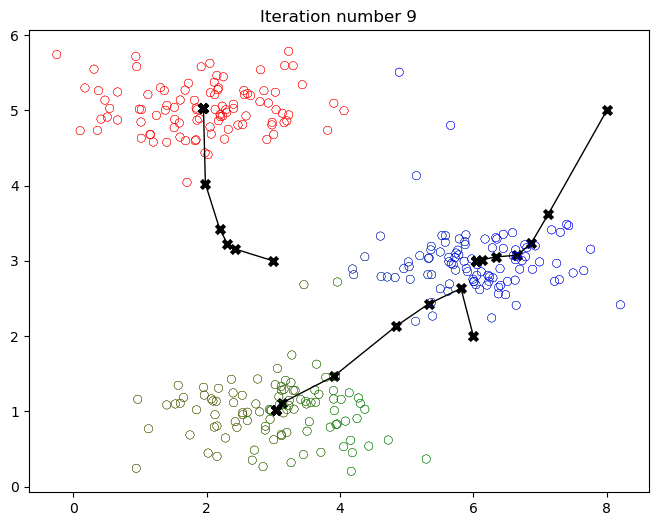

In [21]:
# Load an example dataset
X = np.load("ex7_X.npy")

# Set initial centroids
initial_centroids = np.array([[3,3],[6,2],[8,5]])

# Number of iterations
max_iters = 10

# Run K-Means
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

In [28]:
def kMeans_init_centroids(X, K):
    randidx = np.random.permutation(X.shape[0])
    centroids = X[randidx[:K]]
    return centroids

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


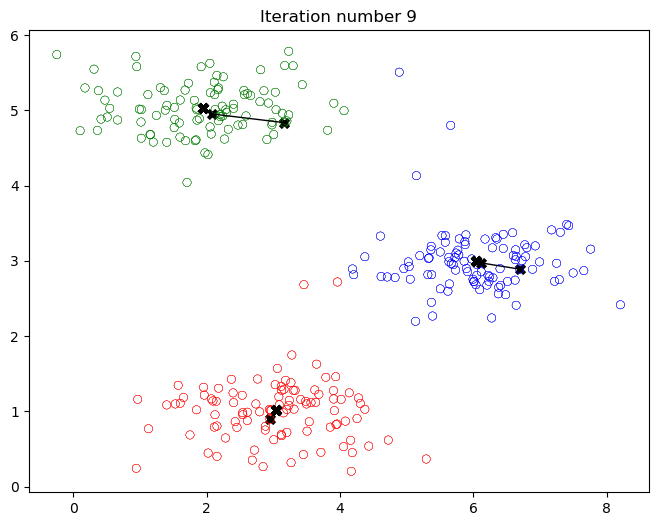

In [36]:
# Set number of centroids and max number of iterations
K = 3
max_iters = 10

# Set initial centroids by picking random examples from the dataset
initial_centroids = kMeans_init_centroids(X, K)

# Run K-Means
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

In [37]:
#Image compression with K-means

In [38]:
original_img = plt.imread('bird_small.png')

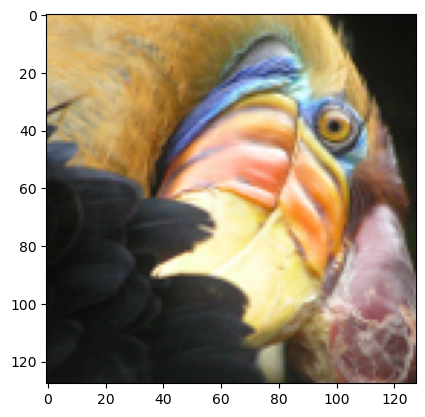

In [39]:
plt.imshow(original_img)

In [40]:
print(original_img.shape)

(128, 128, 3)


In [41]:
X_img = np.reshape(original_img, (original_img.shape[0] *original_img.shape[1], 3))

In [42]:
#K-Means on image pixels


In [44]:
K = 16
max_iters = 10

initial_centroids = kMeans_init_centroids(X_img, K)

centroids, idx = run_kMeans(X_img, initial_centroids, max_iters)

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


<Figure size 800x600 with 0 Axes>

In [45]:
print('SHAPE:',idx.shape)
print('FIRST 5 ELEMENTS:' , idx[:5])

SHAPE: (16384,)
FIRST 5 ELEMENTS: [6 6 6 6 6]


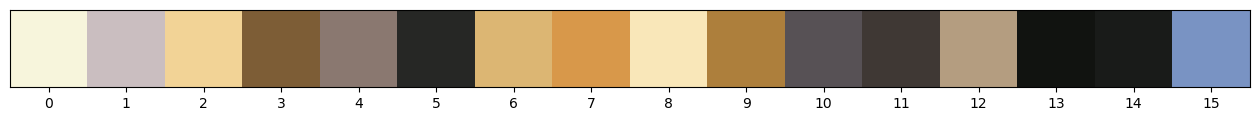

In [47]:
show_centroid_colors(centroids)

In [48]:
idx = find_closest_centroids(X_img, centroids)
X_recovered = centroids[idx, :]
X_recovered = np.reshape(X_recovered, original_img.shape)

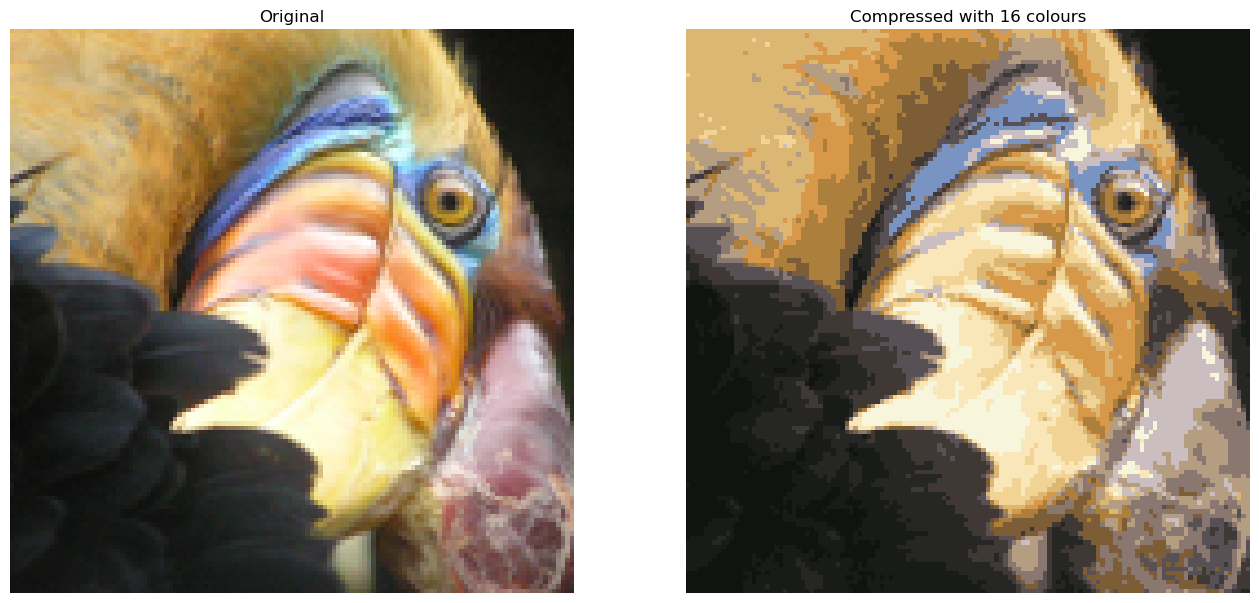

In [49]:
# Display original image
fig, ax = plt.subplots(1,2, figsize=(16,16))
plt.axis('off')

ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].set_axis_off()


# Display compressed image
ax[1].imshow(X_recovered)
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()